# 501: Probability of No Further Warming - Scenario Group Analysis

This notebook calculates the probability that warming declines after net-zero emissions are achieved,
comparing three groups of scenarios:
1. **NZCO2**: Scenarios with "NZCO2" in the label
2. **NZKyoto**: Scenarios with "NZKyoto" in the label
3. **Base**: All other scenarios (no NZCO2 or NZKyoto in label)

**Criteria for decline:**
- Peak warming occurs before 2100
- Delta warming (peak - 2100) > 0°C

In [1]:
import os
from pathlib import Path

import dotenv
import pandas as pd
import matplotlib.pyplot as plt

dotenv.load_dotenv()

True

In [2]:
# Configuration
OUTPUT_FOLDER = Path(os.environ["OUTPUT_FOLDER"])
PLOT_FOLDER = OUTPUT_FOLDER / "plots"
PLOT_FOLDER.mkdir(parents=True, exist_ok=True)

# Guardrails for classifying decline
PEAK_YEAR_THRESHOLD = 2100  # Peak must occur before this year
DELTA_WARMING_THRESHOLD = 0.0  # Minimum decline in °C to count as decline

In [3]:
# Input metrics file - uses combined manifest from 401
MANIFEST_ID = "regenerated"
#METRICS_FILE = OUTPUT_FOLDER / f"500_gsat_metrics_{MANIFEST_ID}.csv"
METRICS_FILE = OUTPUT_FOLDER / f"500b_component_metrics_{MANIFEST_ID}.csv"

## Load and Filter Data

In [4]:
# Load metrics
metrics_df = pd.read_csv(METRICS_FILE)
print(f"Total rows: {len(metrics_df)}")
metrics_df.head()

Total rows: 225


,model,scenario,run_id,peak_year,year_netzero_co2,GSAT|ANTHROPOGENIC|peak,GSAT|ANTHROPOGENIC|netzero_co2,GSAT|ANTHROPOGENIC|2100,GSAT|NonCO2_GHG|peak_gsat,GSAT|NonCO2_GHG|2100,...,GSAT|CO2_NZCO2|peak_gsat,GSAT|CO2_NZCO2|2100,GSAT|CO2_NZCO2|delta_peak_gsat,GSAT|CO2_NZCO2|netzero_co2,GSAT|CO2_NZCO2|delta_netzero_co2,GSAT|CO2_Negative|peak_gsat,GSAT|CO2_Negative|2100,GSAT|CO2_Negative|delta_peak_gsat,GSAT|CO2_Negative|netzero_co2,GSAT|CO2_Negative|delta_netzero_co2
0,AIM/CGE 2.0,SSP1-19,0,2050,2056,1.637086,1.615423,1.418872,0.039674,-0.088367,...,1.547101,1.510393,-0.036708,1.547854,-0.037461,0.000000,-0.082263,-0.082263,0.0,-0.082263
1,AIM/CGE 2.0,SSP1-19,1,2079,2056,2.559779,2.509298,2.543546,0.244876,0.207509,...,2.951047,3.039838,0.088791,2.797172,0.242665,-0.041879,-0.125407,-0.083527,0.0,-0.125407
2,AIM/CGE 2.0,SSP1-19,2,2049,2056,1.773360,1.750914,1.557116,0.048380,-0.095501,...,1.657132,1.651825,-0.005307,1.667820,-0.015995,0.000000,-0.087428,-0.087428,0.0,-0.087428
3,AIM/CGE 2.0,SSP1-19,3,2041,2056,1.382633,1.324147,1.081886,0.071662,-0.123184,...,1.225312,1.146611,-0.078701,1.220179,-0.073568,0.000000,-0.066165,-0.066165,0.0,-0.066165
4,AIM/CGE 2.0,SSP1-19,4,2049,2056,1.648214,1.617597,1.393853,0.114046,-0.049095,...,1.524414,1.465127,-0.059288,1.521438,-0.056311,0.000000,-0.079328,-0.079328,0.0,-0.079328


In [5]:
# Filter for GSAT at NZCO2 year
all_df = metrics_df[["model", "scenario", "run_id", "peak_year", "year_netzero_co2", "GSAT|ANTHROPOGENIC|netzero_co2"]].copy()
all_df

,model,scenario,run_id,peak_year,year_netzero_co2,GSAT|ANTHROPOGENIC|netzero_co2
0,AIM/CGE 2.0,SSP1-19,0,2050,2056,1.615423
1,AIM/CGE 2.0,SSP1-19,1,2079,2056,2.509298
2,AIM/CGE 2.0,SSP1-19,2,2049,2056,1.750914
3,AIM/CGE 2.0,SSP1-19,3,2041,2056,1.324147
4,AIM/CGE 2.0,SSP1-19,4,2049,2056,1.617597
...,...,...,...,...,...,...
220,AIM/CGE V2.2,ENGAGE-Feasibility-1000/Institutional_NZKyoto,20,2052,2060,1.282520
221,AIM/CGE V2.2,ENGAGE-Feasibility-1000/Institutional_NZKyoto,21,2055,2060,1.968699
222,AIM/CGE V2.2,ENGAGE-Feasibility-1000/Institutional_NZKyoto,22,2066,2060,2.277641
223,AIM/CGE V2.2,ENGAGE-Feasibility-1000/Institutional_NZKyoto,23,2047,2060,1.663344


In [6]:
all_df[all_df["peak_year"]<all_df["year_netzero_co2"]]

,model,scenario,run_id,peak_year,year_netzero_co2,GSAT|ANTHROPOGENIC|netzero_co2
0,AIM/CGE 2.0,SSP1-19,0,2050,2056,1.615423
2,AIM/CGE 2.0,SSP1-19,2,2049,2056,1.750914
3,AIM/CGE 2.0,SSP1-19,3,2041,2056,1.324147
4,AIM/CGE 2.0,SSP1-19,4,2049,2056,1.617597
5,AIM/CGE 2.0,SSP1-19,5,2035,2056,1.041977
...,...,...,...,...,...,...
217,AIM/CGE V2.2,ENGAGE-Feasibility-1000/Institutional_NZKyoto,17,2049,2060,1.410665
219,AIM/CGE V2.2,ENGAGE-Feasibility-1000/Institutional_NZKyoto,19,2056,2060,1.357137
220,AIM/CGE V2.2,ENGAGE-Feasibility-1000/Institutional_NZKyoto,20,2052,2060,1.282520
221,AIM/CGE V2.2,ENGAGE-Feasibility-1000/Institutional_NZKyoto,21,2055,2060,1.968699


In [7]:
# Load 500b component metrics
all_df = pd.read_csv(OUTPUT_FOLDER / f"500b_component_metrics_{MANIFEST_ID}.csv")

# Filter to rows where net-zero CO2 year extraction was possible
all_df = all_df[all_df["GSAT|ANTHROPOGENIC|netzero_co2"].notna()].copy()
print(f"Rows with valid NZCO2-year extraction: {len(all_df)}")

# Classify scenarios into groups
all_df["scenario_group"] = all_df["scenario"].apply(
    lambda x: "Stylised Variants (NZCO2-hold)" if "NZCO2" in x
    else ("Stylised Variants (NZGHG-hold)" if "NZKyoto" in x else "Scenarios (NZCO2)")
)
# Build set of (model, stripped_scenario) keys from NZKyoto
nzkyoto_combos = set(
    all_df[all_df["scenario_group"] == "Stylised Variants (NZGHG-hold)"]
    .assign(scenario_key=lambda d: d["scenario"].str.replace("_NZKyoto", "", regex=False))
    [["model", "scenario_key"]]
    .itertuples(index=False, name=None)
)

# Find Base rows whose (model, scenario) pair matches a stripped NZKyoto combo
base_df = all_df[all_df["scenario_group"] == "Scenarios (NZCO2)"]
mask = base_df.apply(
    lambda r: (r["model"], r["scenario"]) in nzkyoto_combos, axis=1
)
base_nzghg = base_df[mask].copy()
base_nzghg["scenario_group"] = "Scenarios (NZGHG)"

# Concatenate without overwriting all_df
all_df_extended = pd.concat([all_df, base_nzghg], ignore_index=True)

# Show group counts
group_counts = (
    all_df_extended
    .drop_duplicates(subset=["model", "scenario", "scenario_group"])
    .groupby("scenario_group")
    .agg(
        n_rows=("run_id", "count"),
        n_unique_model_scenarios=("scenario", "count")
    )
)

print("\nScenario group summary:")
group_counts

Rows with valid NZCO2-year extraction: 225

Scenario group summary:


,n_rows,n_unique_model_scenarios
scenario_group,,
Scenarios (NZCO2),3,3
Scenarios (NZGHG),3,3
Stylised Variants (NZCO2-hold),3,3
Stylised Variants (NZGHG-hold),3,3


In [8]:
nzvals = pd.read_csv("/Users/hoegner/GitHub/ar7_netzero_assessment/analysis/output_revision/101_netzero_timings.csv")
nzvals[nzvals["achieve_netzero_co2"]==True]

,model,scenario,year_netzero_co2,year_netzero_kyoto_ar6gwp100,achieve_netzero_co2,achieve_netzero_ghg
0,AIM/CGE 2.0,SSP1-19,2056.0,2069.0,True,True
5,AIM/CGE 2.0,SSP2-19,2052.0,2061.0,True,True
6,AIM/CGE 2.0,SSP2-26,2074.0,NaN,True,False
11,AIM/CGE 2.0,SSP3-34,2089.0,NaN,True,False
15,AIM/CGE 2.0,SSP4-26,2084.0,NaN,True,False
...,...,...,...,...,...,...
1535,WITCH-GLOBIOM 4.4,CD-LINKS-INDC2030i_1600,2088.0,NaN,True,False
1537,WITCH-GLOBIOM 4.4,CD-LINKS-NDC2030i_1000,2066.0,2079.0,True,True
1539,WITCH-GLOBIOM 4.4,CD-LINKS-NPi2020_1000,2076.0,2087.0,True,True
1540,WITCH-GLOBIOM 4.4,CD-LINKS-NPi2020_1600,2095.0,NaN,True,False


In [9]:
all_df = pd.read_csv(OUTPUT_FOLDER / f"500b_component_metrics_{MANIFEST_ID}.csv")
len(all_df[['model', 'scenario']].copy().drop_duplicates())

9

In [10]:
len(nzvals[['model', 'scenario']].copy().drop_duplicates())

1543

In [11]:
len(nzvals[nzvals["achieve_netzero_ghg"]==True])

388

In [12]:
len(all_df[['model', 'scenario']].copy().drop_duplicates())

9

## Classify Ensemble Members

In [13]:
all_df_extended["GSAT|ANTHROPOGENIC|delta_netzero_co2"] = all_df_extended["GSAT|ANTHROPOGENIC|2100"] - all_df_extended["GSAT|ANTHROPOGENIC|netzero_co2"]
all_df_extended["GSAT|ANTHROPOGENIC|delta_peak_gsat"] = all_df_extended["GSAT|ANTHROPOGENIC|2100"] - all_df_extended["GSAT|ANTHROPOGENIC|peak"]

In [14]:
# Apply guardrails to classify each ensemble member as "decline" or not
all_df_extended["is_decline"] = (
    (all_df_extended["peak_year"] < PEAK_YEAR_THRESHOLD) &
    (all_df_extended["GSAT|ANTHROPOGENIC|delta_netzero_co2"] < DELTA_WARMING_THRESHOLD)
)

# Summary by group
decline_summary = all_df_extended.groupby("scenario_group").agg(
    total_members=("is_decline", "count"),
    decline_members=("is_decline", "sum"),
)
decline_summary["no_decline_members"] = decline_summary["total_members"] - decline_summary["decline_members"]
decline_summary["pct_decline"] = (decline_summary["decline_members"] / decline_summary["total_members"] * 100).round(1)
print("Decline classification by scenario group 2100 - NZCO2 year:")
decline_summary

Decline classification by scenario group 2100 - NZCO2 year:


,total_members,decline_members,no_decline_members,pct_decline
scenario_group,,,,
Scenarios (NZCO2),75,72,3,96.0
Scenarios (NZGHG),75,72,3,96.0
Stylised Variants (NZCO2-hold),75,58,17,77.3
Stylised Variants (NZGHG-hold),75,71,4,94.7


In [15]:
# Apply guardrails to classify each ensemble member as "decline" or not
all_df_extended_gsat = all_df_extended.copy()

all_df_extended_gsat["is_decline"] = (
    (all_df_extended_gsat["peak_year"] < PEAK_YEAR_THRESHOLD) &
    (all_df_extended_gsat["GSAT|ANTHROPOGENIC|delta_peak_gsat"] < DELTA_WARMING_THRESHOLD)
)

# Summary by group
decline_summary_gsat = all_df_extended_gsat.groupby("scenario_group").agg(
    total_members=("is_decline", "count"),
    decline_members=("is_decline", "sum"),
)
decline_summary_gsat["no_decline_members"] = decline_summary_gsat["total_members"] - decline_summary_gsat["decline_members"]
decline_summary_gsat["pct_decline"] = (decline_summary_gsat["decline_members"] / decline_summary_gsat["total_members"] * 100).round(1)
print("Decline classification by scenario group 2100 - peak GSAT year:")
decline_summary_gsat

Decline classification by scenario group 2100 - peak GSAT year:


,total_members,decline_members,no_decline_members,pct_decline
scenario_group,,,,
Scenarios (NZCO2),75,74,1,98.7
Scenarios (NZGHG),75,74,1,98.7
Stylised Variants (NZCO2-hold),75,60,15,80.0
Stylised Variants (NZGHG-hold),75,73,2,97.3


## Calculate Probability Per Scenario from NZCO2 year

In [16]:
# Group by model, scenario, and scenario_group, calculate probability
decline_prob = all_df_extended.groupby(["scenario_group", "model", "scenario"]).agg(
    n_ensemble=pd.NamedAgg(column="run_id", aggfunc="count"),
    n_decline=pd.NamedAgg(column="is_decline", aggfunc="sum"),
).reset_index()

# Calculate probability
decline_prob["prob_decline"] = decline_prob["n_decline"] / decline_prob["n_ensemble"]
decline_prob["prob_decline_pct"] = (decline_prob["prob_decline"] * 100).round(1)

print(f"Calculated probabilities for {len(decline_prob)} scenarios")
decline_prob.head(10)

Calculated probabilities for 12 scenarios


,scenario_group,model,scenario,n_ensemble,n_decline,prob_decline,prob_decline_pct
0,Scenarios (NZCO2),AIM/CGE 2.0,SSP1-19,25,24,0.96,96.0
1,Scenarios (NZCO2),AIM/CGE 2.1,CD-LINKS-NPi2020_400,25,25,1.00,100.0
2,Scenarios (NZCO2),AIM/CGE V2.2,ENGAGE-Feasibility-1000/Institutional,25,23,0.92,92.0
3,Scenarios (NZGHG),AIM/CGE 2.0,SSP1-19,25,24,0.96,96.0
4,Scenarios (NZGHG),AIM/CGE 2.1,CD-LINKS-NPi2020_400,25,25,1.00,100.0
5,Scenarios (NZGHG),AIM/CGE V2.2,ENGAGE-Feasibility-1000/Institutional,25,23,0.92,92.0
6,Stylised Variants (NZCO2-hold),AIM/CGE 2.0,SSP1-19_NZCO2,25,24,0.96,96.0
7,Stylised Variants (NZCO2-hold),AIM/CGE 2.1,CD-LINKS-NPi2020_400_NZCO2,25,24,0.96,96.0
8,Stylised Variants (NZCO2-hold),AIM/CGE V2.2,ENGAGE-Feasibility-1000/Institutional_NZCO2,25,10,0.40,40.0
9,Stylised Variants (NZGHG-hold),AIM/CGE 2.0,SSP1-19_NZKyoto,25,24,0.96,96.0


In [17]:
# Create structured summary table for each group
def create_group_summary(df, group_name):
    """Create summary statistics for a scenario group."""
    group_data = df[df["scenario_group"] == group_name]
    
    summary = {
        "Group": group_name,
        "N Scenarios": len(group_data),
        "Median (%)": group_data["prob_decline_pct"].median().round(1),
        "5th Pctl (%)": group_data["prob_decline_pct"].quantile(0.05).round(1),
        "17th Pctl (%)": group_data["prob_decline_pct"].quantile(0.17).round(1),
        "10th Pctl (%)": group_data["prob_decline_pct"].quantile(0.1).round(1),
        "34th Pctl (%)": group_data["prob_decline_pct"].quantile(0.34).round(1),
        "67th Pctl (%)": group_data["prob_decline_pct"].quantile(0.67).round(1),
        "83rd Pctl (%)": group_data["prob_decline_pct"].quantile(0.83).round(1),
        "90th Pctl (%)": group_data["prob_decline_pct"].quantile(0.9).round(1),
        "95th Pctl (%)": group_data["prob_decline_pct"].quantile(0.95).round(1),
    }
    return summary

# Create summary for each group
summaries = []
for group in ["Scenarios (NZCO2)", "Scenarios (NZGHG)", "Stylised Variants (NZCO2-hold)", "Stylised Variants (NZGHG-hold)"]:
    summaries.append(create_group_summary(decline_prob, group))

summary_table = pd.DataFrame(summaries)
print("Summary Table: Probability of Peak-and-Decline behavior by Scenario Group")
summary_table

Summary Table: Probability of Peak-and-Decline behavior by Scenario Group


,Group,N Scenarios,Median (%),5th Pctl (%),17th Pctl (%),10th Pctl (%),34th Pctl (%),67th Pctl (%),83rd Pctl (%),90th Pctl (%),95th Pctl (%)
0,Scenarios (NZCO2),3,96.0,92.4,93.4,92.8,94.7,97.4,98.6,99.2,99.6
1,Scenarios (NZGHG),3,96.0,92.4,93.4,92.8,94.7,97.4,98.6,99.2,99.6
2,Stylised Variants (NZCO2-hold),3,96.0,45.6,59.0,51.2,78.1,96.0,96.0,96.0,96.0
3,Stylised Variants (NZGHG-hold),3,96.0,92.4,93.4,92.8,94.7,96.0,96.0,96.0,96.0


In [18]:
rename_map = {
    "Scenarios (NZCO2)":         "Scenarios\n(NZCO2)",
    "Scenarios (NZGHG)":         "Scenarios\n(NZGHG)",
    "Stylised Variants (NZCO2-hold)": "Stylised Variants\n(NZCO2-hold)",
    "Stylised Variants (NZGHG-hold)": "Stylised Variants\n(NZGHG-hold)",
}

summary_table["Group"] = summary_table["Group"].replace(rename_map)

In [19]:
summary_table

,Group,N Scenarios,Median (%),5th Pctl (%),17th Pctl (%),10th Pctl (%),34th Pctl (%),67th Pctl (%),83rd Pctl (%),90th Pctl (%),95th Pctl (%)
0,Scenarios\n(NZCO2),3,96.0,92.4,93.4,92.8,94.7,97.4,98.6,99.2,99.6
1,Scenarios\n(NZGHG),3,96.0,92.4,93.4,92.8,94.7,97.4,98.6,99.2,99.6
2,Stylised Variants\n(NZCO2-hold),3,96.0,45.6,59.0,51.2,78.1,96.0,96.0,96.0,96.0
3,Stylised Variants\n(NZGHG-hold),3,96.0,92.4,93.4,92.8,94.7,96.0,96.0,96.0,96.0


In [20]:
fig, ax = plt.subplots(figsize=(11, len(summary_table) * 0.2))
ax.axis("off")

table = ax.table(
    cellText=summary_table.values,
    colLabels=summary_table.columns,
  #  rowLabels=summary_table.index,
    loc="center",
    cellLoc="center",  # centers cell contents
    colLoc="center",   # centers column headers
)

table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1.3,1.9)

header_height = 0.3  # adjust to taste
for col_idx in range(len(summary_table.columns)):
    table[0, col_idx].set_height(header_height)
    table[0, col_idx].get_text().set_fontweight("bold")
    table[0, col_idx].set_facecolor("#e0e0e0")
    
# Bold column headers (row index 0)
for col_idx in range(len(summary_table.columns)):
    table[0, col_idx].get_text().set_fontweight("bold")
    table[0, col_idx].set_facecolor("#e0e0e0")  # light grey background

fig.savefig(PLOT_FOLDER / "501_nfw_nzco2_table.png", bbox_inches="tight", dpi=300)
plt.close(fig)

In [21]:
groups = [
    "Scenarios (NZCO2)",
    "Scenarios (NZGHG)",
    "Stylised Variants (NZCO2-hold)",
    "Stylised Variants (NZGHG-hold)",
]

def format_decline_summary(df, group_name):
    group_data = df[df["scenario_group"] == group_name]["prob_decline_pct"]
    return [
        f"{group_data.median():.1f}%",
        f"({group_data.quantile(0.17):.1f}% to {group_data.quantile(0.83):.1f}%)",
        f"({group_data.quantile(0.05):.1f}% to {group_data.quantile(0.95):.1f}%)",
    ]

stat_labels = [
    "Median [%]",
    "(p34 to p67) [%]",
    "(p17 to p83) [%]",
    "(p10 to p90) [%]",
    "(p05 to p95) [%]",
    "N scenarios",

]

def format_decline_summary(df, group_name):
    group_data = df[df["scenario_group"] == group_name]["prob_decline_pct"]
    return [
        f"{group_data.median():.1f}%",
        f"({group_data.quantile(0.34):.1f}% to {group_data.quantile(0.67):.1f}%)",
        f"({group_data.quantile(0.17):.1f}% to {group_data.quantile(0.83):.1f}%)",
        f"({group_data.quantile(0.10):.1f}% to {group_data.quantile(0.90):.1f}%)",
        f"({group_data.quantile(0.05):.1f}% to {group_data.quantile(0.95):.1f}%)",
        f"{len(group_data)}",
    ]

rows = []
for stat_label, val_idx in zip(stat_labels, [0, 1, 2, 3, 4, 5]):
    row = {"Statistic": stat_label}
    for grp in groups:
        vals = format_decline_summary(decline_prob, grp)
        row[grp] = vals[val_idx]
    rows.append(row)

decline_summary_table = pd.DataFrame(rows).set_index("Statistic")
decline_summary_table.columns = decline_summary_table.columns.map(rename_map)

# Plot
fig, ax = plt.subplots(figsize=(6, len(decline_summary_table) * 0.3 + 0.1))
ax.axis("off")
table = ax.table(
    cellText=decline_summary_table.values,
    colLabels=decline_summary_table.columns,
    rowLabels=list(decline_summary_table.index),
    loc="center",
    cellLoc="center",
    colLoc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 1.5)

header_height = 0.2
for col_idx in range(len(decline_summary_table.columns)):
    table[0, col_idx].set_height(header_height)
    table[0, col_idx].get_text().set_fontweight("bold")
    table[0, col_idx].set_facecolor("#e0e0e0")

fig.savefig(PLOT_FOLDER / "501_decline_prob_table.png", bbox_inches="tight", dpi=300)
plt.close(fig)

In [22]:
all_df_extended.to_csv(OUTPUT_FOLDER / f"500b_component_metrics_extended_{MANIFEST_ID}.csv")

## Calculate Probability Per Scenario from peak GSAT year

In [23]:
# Group by model, scenario, and scenario_group, calculate probability
decline_prob = all_df_extended_gsat.groupby(["scenario_group", "model", "scenario"]).agg(
    n_ensemble=pd.NamedAgg(column="run_id", aggfunc="count"),
    n_decline=pd.NamedAgg(column="is_decline", aggfunc="sum"),
).reset_index()

# Calculate probability
decline_prob["prob_decline"] = decline_prob["n_decline"] / decline_prob["n_ensemble"]
decline_prob["prob_decline_pct"] = (decline_prob["prob_decline"] * 100).round(1)

print(f"Calculated probabilities for {len(decline_prob)} scenarios")
decline_prob.head(10)

Calculated probabilities for 12 scenarios


,scenario_group,model,scenario,n_ensemble,n_decline,prob_decline,prob_decline_pct
0,Scenarios (NZCO2),AIM/CGE 2.0,SSP1-19,25,25,1.00,100.0
1,Scenarios (NZCO2),AIM/CGE 2.1,CD-LINKS-NPi2020_400,25,25,1.00,100.0
2,Scenarios (NZCO2),AIM/CGE V2.2,ENGAGE-Feasibility-1000/Institutional,25,24,0.96,96.0
3,Scenarios (NZGHG),AIM/CGE 2.0,SSP1-19,25,25,1.00,100.0
4,Scenarios (NZGHG),AIM/CGE 2.1,CD-LINKS-NPi2020_400,25,25,1.00,100.0
5,Scenarios (NZGHG),AIM/CGE V2.2,ENGAGE-Feasibility-1000/Institutional,25,24,0.96,96.0
6,Stylised Variants (NZCO2-hold),AIM/CGE 2.0,SSP1-19_NZCO2,25,24,0.96,96.0
7,Stylised Variants (NZCO2-hold),AIM/CGE 2.1,CD-LINKS-NPi2020_400_NZCO2,25,24,0.96,96.0
8,Stylised Variants (NZCO2-hold),AIM/CGE V2.2,ENGAGE-Feasibility-1000/Institutional_NZCO2,25,12,0.48,48.0
9,Stylised Variants (NZGHG-hold),AIM/CGE 2.0,SSP1-19_NZKyoto,25,24,0.96,96.0


In [24]:
# Create summary for each group
summaries = []
for group in ["Scenarios (NZCO2)", "Scenarios (NZGHG)", "Stylised Variants (NZCO2-hold)", "Stylised Variants (NZGHG-hold)"]:
    summaries.append(create_group_summary(decline_prob, group))

summary_table = pd.DataFrame(summaries)
print("Summary Table: Probability of Peak-and-Decline behavior by Scenario Group")
summary_table

Summary Table: Probability of Peak-and-Decline behavior by Scenario Group


,Group,N Scenarios,Median (%),5th Pctl (%),17th Pctl (%),10th Pctl (%),34th Pctl (%),67th Pctl (%),83rd Pctl (%),90th Pctl (%),95th Pctl (%)
0,Scenarios (NZCO2),3,100.0,96.4,97.4,96.8,98.7,100.0,100.0,100.0,100.0
1,Scenarios (NZGHG),3,100.0,96.4,97.4,96.8,98.7,100.0,100.0,100.0,100.0
2,Stylised Variants (NZCO2-hold),3,96.0,52.8,64.3,57.6,80.6,96.0,96.0,96.0,96.0
3,Stylised Variants (NZGHG-hold),3,96.0,96.0,96.0,96.0,96.0,97.4,98.6,99.2,99.6


In [25]:
summary_table["Group"] = summary_table["Group"].replace(rename_map)

fig, ax = plt.subplots(figsize=(11, len(summary_table) * 0.2))
ax.axis("off")

table = ax.table(
    cellText=summary_table.values,
    colLabels=summary_table.columns,
  #  rowLabels=summary_table.index,
    loc="center",
    cellLoc="center",  # centers cell contents
    colLoc="center",   # centers column headers
)

# Bold column headers (row index 0)
for col_idx in range(len(summary_table.columns)):
    table[0, col_idx].get_text().set_fontweight("bold")
    table[0, col_idx].set_facecolor("#e0e0e0")  # light grey background

table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1.3,1.9)

header_height = 0.3  # adjust to taste
for col_idx in range(len(summary_table.columns)):
    table[0, col_idx].set_height(header_height)
    table[0, col_idx].get_text().set_fontweight("bold")
    table[0, col_idx].set_facecolor("#e0e0e0")

fig.savefig(PLOT_FOLDER / "501_nfw_peak_gsat_table.png", bbox_inches="tight", dpi=300)
plt.close(fig)

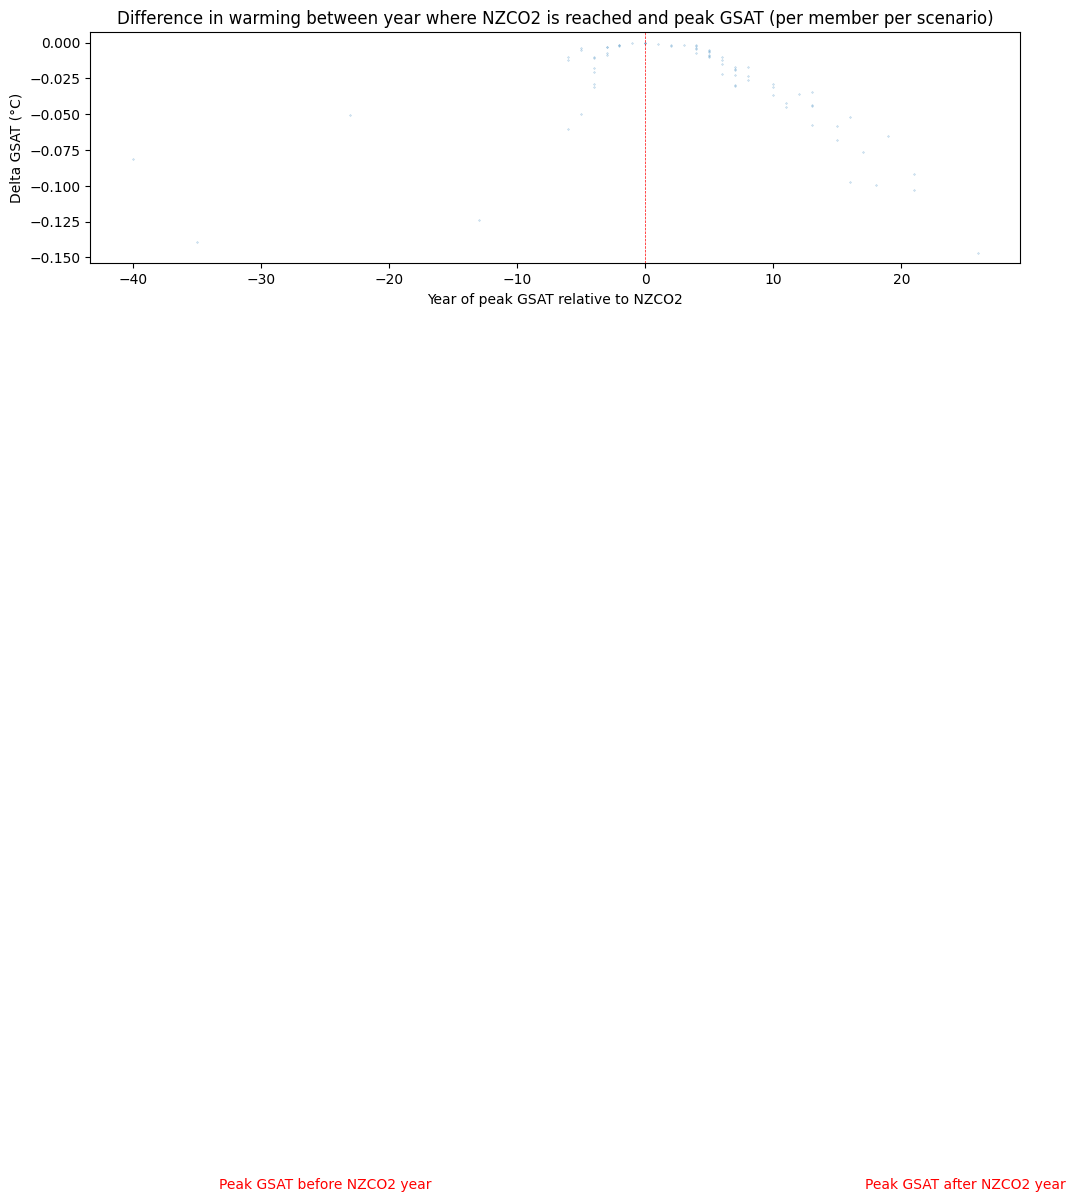

In [26]:
fig, ax = plt.subplots(figsize=(12, 3))

subset = all_df_extended[all_df_extended["scenario_group"]=="Scenarios (NZCO2)"]

x = subset["year_netzero_co2"] - subset["peak_year"]
y = subset["GSAT|ANTHROPOGENIC|netzero_co2"] - subset["GSAT|ANTHROPOGENIC|peak"]

ax.scatter(x, y, marker='x', s=0.8, alpha=.2)
ax.axvline(x=0, linestyle='--', c='red', linewidth=0.5)

# Position text near the top of the plot
y_text = -0.8

ax.text(
    -25,  # halfway between xmin and 0
    y_text,
    "Peak GSAT before NZCO2 year",
    ha="center",
    c="red"
)

ax.text(
    25,     # halfway between 0 and xmax
    y_text,
    "Peak GSAT after NZCO2 year",
    ha="center",
    c="red"
)

ax.set_title("Difference in warming between year where NZCO2 is reached and peak GSAT (per member per scenario)")
ax.set_xlabel("Year of peak GSAT relative to NZCO2")
ax.set_ylabel("Delta GSAT (°C)")

fig.savefig(PLOT_FOLDER / "501_peak_v_nzco2_timing.png", bbox_inches="tight", dpi=300)
    
plt.show()


# the delta is obviously negative or zero by definition, since otherwise the two years coincide

## Detailed Results by Group

In [27]:
# Base scenarios (no NZCO2 or NZKyoto)
print("Scenarios (NZCO2) (no net-zero suffix)")
print("=" * 50)
base_results = decline_prob[decline_prob["scenario_group"] == "Scenarios (NZCO2)"][
    ["model", "scenario", "n_ensemble", "n_decline", "prob_decline_pct"]
].sort_values("prob_decline_pct", ascending=False)
base_results

Scenarios (NZCO2) (no net-zero suffix)


,model,scenario,n_ensemble,n_decline,prob_decline_pct
0,AIM/CGE 2.0,SSP1-19,25,25,100.0
1,AIM/CGE 2.1,CD-LINKS-NPi2020_400,25,25,100.0
2,AIM/CGE V2.2,ENGAGE-Feasibility-1000/Institutional,25,24,96.0


In [28]:
# Base scenarios (no NZCO2 or NZKyoto)
print("Scenarios (NZGHG) (no net-zero suffix)")
print("=" * 50)
base_results = decline_prob[decline_prob["scenario_group"] == "Scenarios (NZGHG)"][
    ["model", "scenario", "n_ensemble", "n_decline", "prob_decline_pct"]
].sort_values("prob_decline_pct", ascending=False)
base_results

Scenarios (NZGHG) (no net-zero suffix)


,model,scenario,n_ensemble,n_decline,prob_decline_pct
3,AIM/CGE 2.0,SSP1-19,25,25,100.0
4,AIM/CGE 2.1,CD-LINKS-NPi2020_400,25,25,100.0
5,AIM/CGE V2.2,ENGAGE-Feasibility-1000/Institutional,25,24,96.0


In [29]:
# NZKyoto scenarios
print("Stylised Variants (NZGHG-hold)")
print("=" * 50)
nzkyoto_results = decline_prob[decline_prob["scenario_group"] == "Stylised Variants (NZGHG-hold)"][
    ["model", "scenario", "n_ensemble", "n_decline", "prob_decline_pct"]
].sort_values("prob_decline_pct", ascending=False)
nzkyoto_results

Stylised Variants (NZGHG-hold)


,model,scenario,n_ensemble,n_decline,prob_decline_pct
10,AIM/CGE 2.1,CD-LINKS-NPi2020_400_NZKyoto,25,25,100.0
9,AIM/CGE 2.0,SSP1-19_NZKyoto,25,24,96.0
11,AIM/CGE V2.2,ENGAGE-Feasibility-1000/Institutional_NZKyoto,25,24,96.0


In [30]:
# NZCO2 scenarios
print("Stylised Variants (NZCO2-hold)")
print("=" * 50)
nzco2_results = decline_prob[decline_prob["scenario_group"] == "Stylised Variants (NZCO2-hold)"][
    ["model", "scenario", "n_ensemble", "n_decline", "prob_decline_pct"]
].sort_values("prob_decline_pct", ascending=False)
nzco2_results

Stylised Variants (NZCO2-hold)


,model,scenario,n_ensemble,n_decline,prob_decline_pct
6,AIM/CGE 2.0,SSP1-19_NZCO2,25,24,96.0
7,AIM/CGE 2.1,CD-LINKS-NPi2020_400_NZCO2,25,24,96.0
8,AIM/CGE V2.2,ENGAGE-Feasibility-1000/Institutional_NZCO2,25,12,48.0
